<a href="https://colab.research.google.com/github/Methura/Methura-PM/blob/main/rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 227ms/step - accuracy: 0.7589 - loss: 0.4917 - val_accuracy: 0.8344 - val_loss: 0.3828
Epoch 2/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 72s 228ms/step - accuracy: 0.8788 - loss: 0.3006 - val_accuracy: 0.8430 - val_loss: 0.3533
Epoch 3/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 223ms/step - accuracy: 0.9083 - loss: 0.2357 - val_accuracy: 0.8694 - val_loss: 0.3290
Epoch 4/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 226ms/step - accuracy: 0.9290 - loss: 0.1918 - val_accuracy: 0.8686 - val_loss: 0.3251
Epoch 5/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 72s 229ms/step - accuracy: 0.9417 - loss: 0.1577 - val_accuracy: 0.8652 - val_loss: 0.3560
Epoch 6/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 226ms/step - accuracy: 0.9478 - loss: 0.1409 - val_accuracy: 0.8596 - val_loss: 0.3912
Epoch 7/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 220ms/step - accuracy: 0.9621 - loss: 0.1049 - val_accuracy: 0.8620 - val_loss: 0.5024
Epoch 8/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 226ms/step - accuracy: 0.9641 - loss: 0

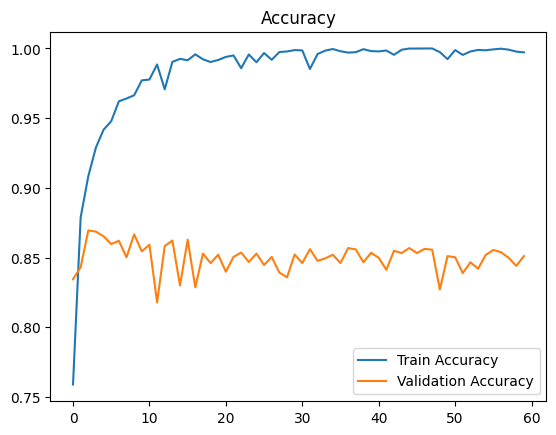

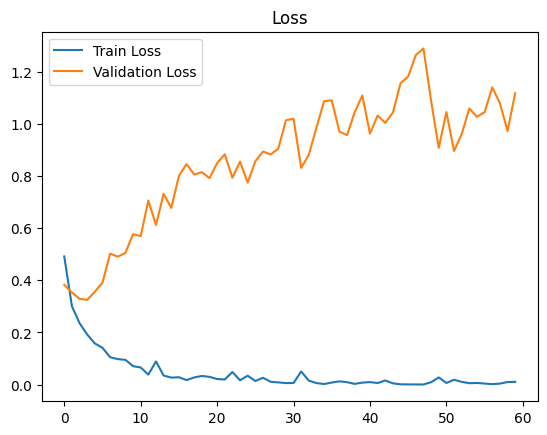

782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.8528 - loss: 1.0910
Test Accuracy: 0.8527600169181824
Test Loss: 1.0910102128982544
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step


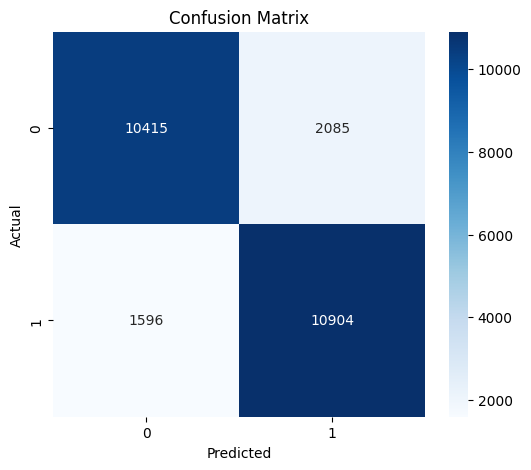

              precision    recall  f1-score   support

           0       0.87      0.83      0.85     12500
           1       0.84      0.87      0.86     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



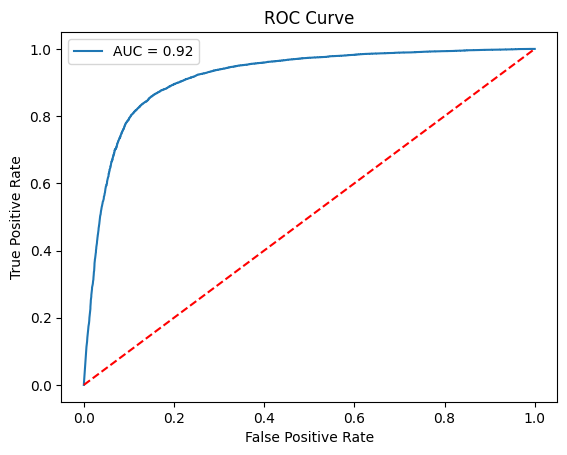

In [ ]:
!pip install scikit-learn

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
# Load IMDB dataset (top 5000 words)
vocab_size = 5000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))
max_len = 200

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)
model = Sequential()

model.add(Embedding(vocab_size, 128, input_length=max_len))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.summary()
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
history = model.fit(
    x_train, y_train,
    epochs=60,
    batch_size=64,
    validation_split=0.2
)
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)
print("Test Loss:", loss)
y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
print(classification_report(y_test, y_pred))
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

